## Data Analysis

In [486]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf
import numpy as np
import math as math

In [487]:
storage_path = "../data/gold/monthly_registration_volume_gold.parquet"
#storage_path = "../data/processed/historical_consumer_price_index.parquet"
df = pd.read_parquet(storage_path, engine='pyarrow')
df.head()

,Date,ts_key,Value,Employment_Level,Employment_Level_Change,Employment_Level_Relative_Change,Employment_Level_YoY_Change,Employment_Level_YoY_Relative_Change,Employment_Level_MA_3,Employment_Level_MA_6,consumer_price_index,YoY_change,MoM_change,Deposit_Rate,Deposit_Rate_Change,Deposit_Rate_Relative_Change,Deposit_Rate_YoY_Change,GDP,Lending_Rate,Lending_Rate_Change,Lending_Rate_Relative_Change,Lending_Rate_YoY_Change,Lending_Rate_YoY_Relative_Change,GR_price_with_tax_euro95,GR_price_with_tax_diesel,GR_price_with_tax_heGRing_oil,GR_price_with_tax_fuel_oil_1
0,2018-01-31,ALFA ROMEO_GIULIA_All_Wheel_Drive,54.0,32504413,-104455.0,-0.00320,796982.0,0.02514,3.264763e+07,3.264138e+07,96.4,1.4,0.0031,-0.4,0.0,0.0,0.0,104.34,0.25,0.0,0.0,0.0,0.0,1550.0,1326.0,1018.0,442.14
1,2018-02-28,ALFA ROMEO_GIULIA_All_Wheel_Drive,23.0,32550748,46335.0,0.00143,776950.0,0.02445,3.255468e+07,3.266715e+07,96.7,1.2,0.0031,-0.4,0.0,0.0,0.0,104.34,0.25,0.0,0.0,0.0,0.0,1550.0,1325.0,1010.0,424.16
2,2018-03-31,ALFA ROMEO_GIULIA_All_Wheel_Drive,85.0,32660492,109744.0,0.00337,730269.0,0.02287,3.257188e+07,3.265527e+07,97.2,1.5,0.0052,-0.4,0.0,0.0,0.0,102.81,0.25,0.0,0.0,0.0,0.0,1533.0,1309.0,991.0,431.53
3,2018-04-30,ALFA ROMEO_GIULIA_All_Wheel_Drive,51.0,32782173,121681.0,0.00373,768929.0,0.02402,3.266447e+07,3.265605e+07,97.5,1.4,0.0031,-0.4,0.0,0.0,0.0,102.81,0.25,0.0,0.0,0.0,0.0,1575.0,1348.0,1025.0,453.57
4,2018-05-31,ALFA ROMEO_GIULIA_All_Wheel_Drive,77.0,32857311,75138.0,0.00229,725968.0,0.02259,3.276666e+07,3.266067e+07,98.2,2.1,0.0072,-0.4,0.0,0.0,0.0,102.81,0.25,0.0,0.0,0.0,0.0,1647.0,1420.0,1025.0,520.12


In [488]:
df.shape

(107922, 27)

In [489]:
#How mandy unique values are in column ts_key
df['ts_key'].nunique()

1502

In [490]:
df.describe(include='number')

,Value,Employment_Level,Employment_Level_Change,Employment_Level_Relative_Change,Employment_Level_YoY_Change,Employment_Level_YoY_Relative_Change,Employment_Level_MA_3,Employment_Level_MA_6,consumer_price_index,YoY_change,MoM_change,Deposit_Rate,Deposit_Rate_Change,Deposit_Rate_Relative_Change,Deposit_Rate_YoY_Change,GDP,Lending_Rate,Lending_Rate_Change,Lending_Rate_Relative_Change,Lending_Rate_YoY_Change,Lending_Rate_YoY_Relative_Change,GR_price_with_tax_euro95,GR_price_with_tax_diesel,GR_price_with_tax_heGRing_oil,GR_price_with_tax_fuel_oil_1
count,107922.000000,1.079220e+05,107922.000000,107922.000000,107922.000000,107922.000000,1.079220e+05,1.079220e+05,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000,107922.000000
mean,432.672254,3.422524e+07,27829.439716,0.000828,326445.659189,0.009776,3.419907e+07,3.416495e+07,109.419291,3.119176,0.002613,1.146162,0.023221,0.006211,0.389422,103.886658,1.817026,0.019529,0.038314,0.344543,1.450257,1747.088091,1525.937446,1153.416773,578.549353
std,874.724017,7.264338e+05,142633.827046,0.004176,269263.990743,0.008210,7.263379e+05,7.310082e+05,9.077779,2.362142,0.004190,1.828114,0.180652,0.160245,1.403329,2.547734,1.799459,0.191443,0.239102,1.472018,3.761546,203.724732,222.776195,206.078441,109.310115
min,0.000000,3.250441e+07,-227686.000000,-0.006760,-146294.000000,-0.004310,3.255468e+07,3.264138e+07,96.400000,-0.600000,-0.008100,-0.500000,-0.250000,-1.000000,-1.750000,91.660000,0.250000,-0.600000,-0.133330,-2.100000,-0.466670,1324.000000,1106.000000,753.000000,260.670000
25%,4.000000,3.361020e+07,-49205.000000,-0.001420,96509.000000,0.002750,3.357897e+07,3.359857e+07,100.100000,1.600000,0.000800,-0.500000,0.000000,0.000000,-0.100000,102.740000,0.250000,0.000000,0.000000,0.000000,0.000000,1598.000000,1383.000000,1025.000000,500.310000
50%,88.000000,3.444509e+07,23005.000000,0.000660,316745.000000,0.009220,3.438234e+07,3.430897e+07,109.800000,2.200000,0.002600,-0.400000,0.000000,0.000000,0.000000,104.480000,0.250000,0.000000,0.000000,0.000000,0.000000,1751.000000,1533.000000,1134.000000,667.830000
75%,459.000000,3.486330e+07,78233.000000,0.002290,575362.000000,0.016780,3.485102e+07,3.484062e+07,118.600000,4.300000,0.004300,3.000000,0.000000,0.000000,0.500000,105.470000,3.650000,0.000000,0.000000,0.500000,0.266670,1889.000000,1658.000000,1293.000000,667.830000
max,22335.000000,3.523686e+07,328333.000000,0.009760,796982.000000,0.025140,3.522653e+07,3.507294e+07,122.600000,8.800000,0.019800,4.000000,0.750000,1.000000,4.000000,107.020000,4.750000,0.750000,2.000000,4.000000,16.000000,2400.000000,2126.000000,1606.000000,667.830000


In [491]:
#Shoq all columns in the df.info() output
pd.set_option('display.max_columns', None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107922 entries, 0 to 107921
Data columns (total 27 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   Date                                  107922 non-null  datetime64[ns]
 1   ts_key                                107922 non-null  object        
 2   Value                                 107922 non-null  float64       
 3   Employment_Level                      107922 non-null  int64         
 4   Employment_Level_Change               107922 non-null  float64       
 5   Employment_Level_Relative_Change      107922 non-null  float64       
 6   Employment_Level_YoY_Change           107922 non-null  float64       
 7   Employment_Level_YoY_Relative_Change  107922 non-null  float64       
 8   Employment_Level_MA_3                 107922 non-null  float64       
 9   Employment_Level_MA_6                 107922 non-null  floa

In [492]:
#parse the first term befor the underscore in column ts_key and write it to new column oem
df["oem"] = df["ts_key"].str.extract(r"^([^_]+)_")

df['oem'].unique()

array(['ALFA ROMEO', 'ALPINE', 'ASTON MARTIN', 'AUDI', 'BENTLEY', 'BMW',
       'BYD', 'CADILLAC', 'CITROEN', 'DACIA', 'FERRARI', 'FIAT', 'FISKER',
       'FORD', 'GWM', 'HONDA', 'HYUNDAI', 'INEOS', 'IVECO', 'JAGUAR',
       'JEEP', 'KIA', 'LADA', 'LAMBORGHINI', 'LAND ROVER', 'LEAPMOTOR',
       'LEXUS', 'LOTUS', 'LUCID', 'LYNK & CO', 'MAN', 'MASERATI', 'MAXUS',
       'MAZDA', 'MERCEDES', 'MG ROEWE', 'MINI', 'MITSUBISHI', 'MORGAN',
       'NIO', 'NISSAN', 'OPEL', 'PEUGEOT', 'POLESTAR', 'PORSCHE',
       'RENAULT', 'ROLLS ROYCE', 'SEAT', 'SKODA', 'SMART', 'SUBARU',
       'SUZUKI', 'TESLA', 'TOYOTA', 'VINFAST', 'VOLVO', 'VW', 'XPENG'],
      dtype=object)

In [493]:
types = [
    "All_Wheel_Drive",
    "Diesel",
    "Petrol",
    "Total",
    "BEV",
    "Hybrid",
    "Convertibles"
]

pattern = "(" + "|".join(types) + ")"

df["type"] = df["ts_key"].str.extract(pattern)

#show all null values in new column type
df['type'].unique()

array(['All_Wheel_Drive', 'Diesel', 'Petrol', 'Total', 'BEV', 'Hybrid',
       'Convertibles'], dtype=object)

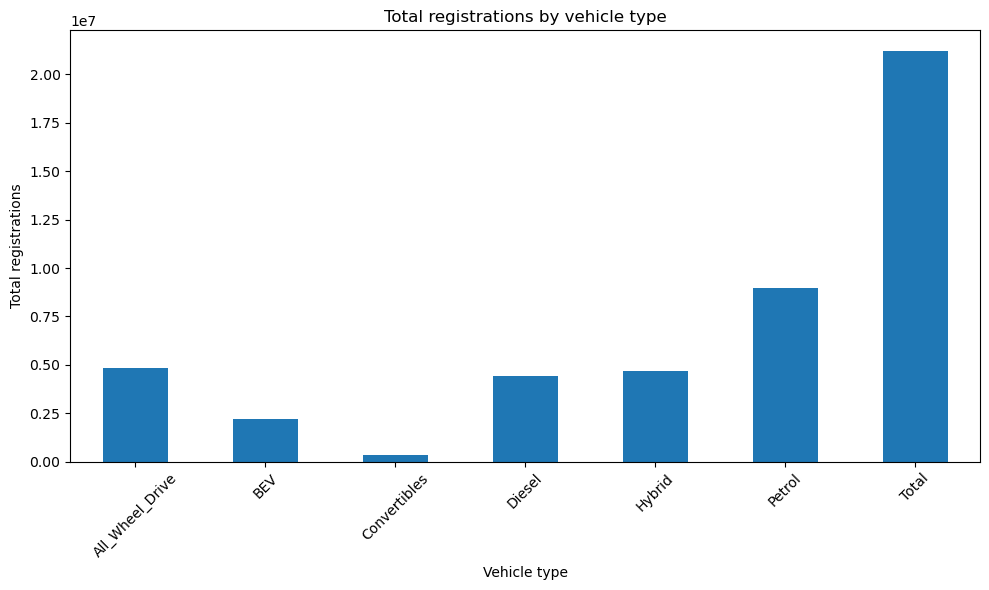

In [494]:
sum_by_type = df.groupby("type")["Value"].sum()

plt.figure(figsize=(10, 6))
sum_by_type.plot(kind="bar")
plt.ylabel("Total registrations")
plt.xlabel("Vehicle type")
plt.title("Total registrations by vehicle type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

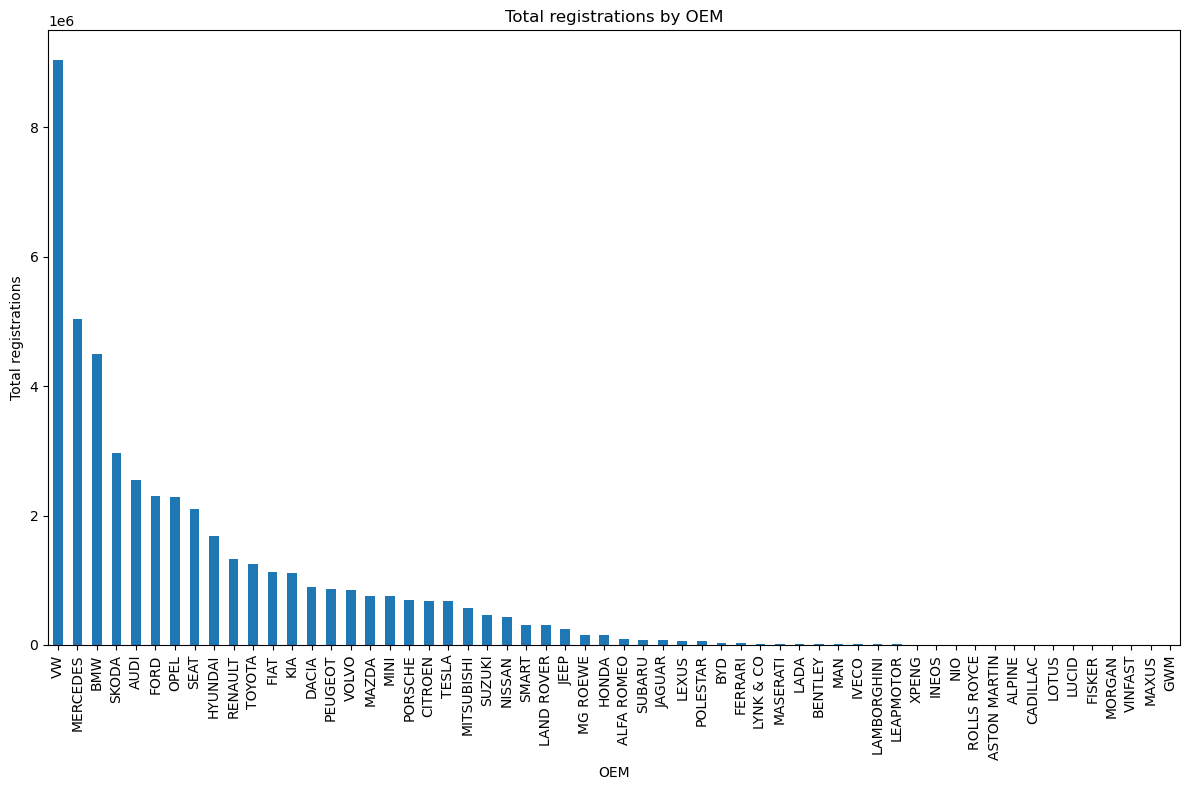

In [495]:
sum_by_oem = df.groupby("oem")["Value"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sum_by_oem.plot(kind="bar")
plt.ylabel("Total registrations")
plt.xlabel("OEM")
plt.title("Total registrations by OEM")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Static Correlation

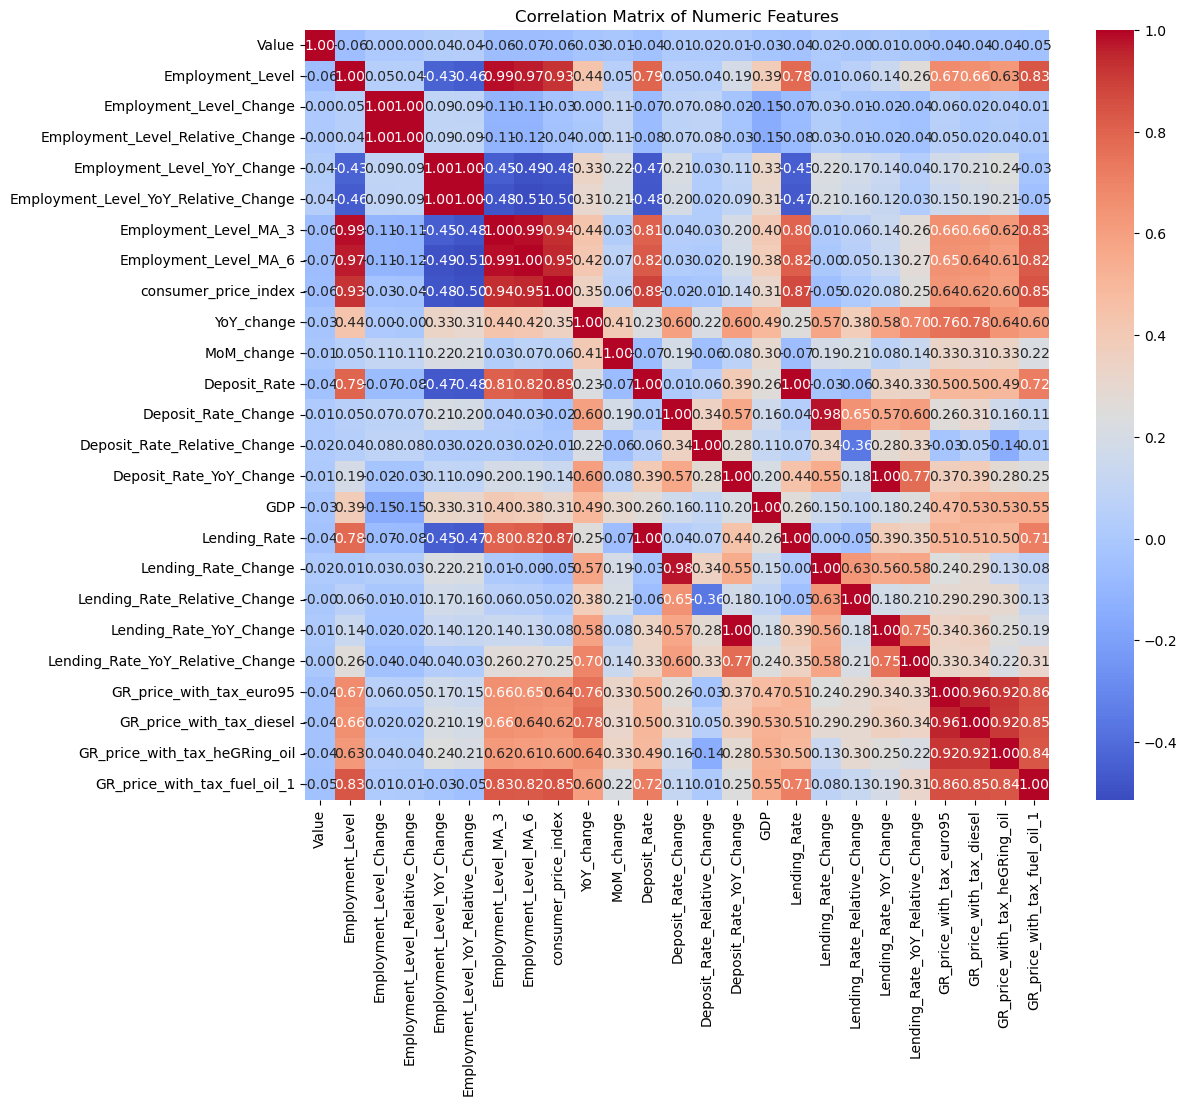

In [496]:
# build dataframe with all numeric columns only
numeric_df = df.select_dtypes(include=['number'])   
# show correlation matrix of numeric columns

plt.figure(figsize=(12,10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [497]:

types = df['type'].unique().tolist()
num_cols = df.select_dtypes(include="number").columns

corr_list = []
for t in types:
    corr_t = (
        df[df["type"] == t][num_cols]
        .corr()["Value"]
        .drop("Value")
        .rename(t)
    )
    corr_list.append(corr_t)

corr_table = pd.concat(corr_list, axis=1).round(2)

styled = (
    corr_table
    .style
    .background_gradient(
        cmap="RdBu_r",   # rot = negativ, blau = positiv
        axis=None,
        vmin=-1, vmax=1
    )

)

styled


,All_Wheel_Drive,Diesel,Petrol,Total,BEV,Hybrid,Convertibles
Employment_Level,-0.050000,-0.170000,-0.170000,-0.110000,0.140000,0.230000,-0.100000
Employment_Level_Change,-0.000000,-0.000000,0.010000,0.000000,-0.010000,-0.010000,0.020000
Employment_Level_Relative_Change,-0.000000,0.000000,0.010000,0.000000,-0.010000,-0.010000,0.020000
Employment_Level_YoY_Change,0.040000,0.080000,0.100000,0.060000,-0.050000,-0.150000,0.040000
Employment_Level_YoY_Relative_Change,0.040000,0.090000,0.100000,0.060000,-0.060000,-0.160000,0.050000
Employment_Level_MA_3,-0.050000,-0.170000,-0.180000,-0.110000,0.140000,0.230000,-0.100000
Employment_Level_MA_6,-0.050000,-0.170000,-0.180000,-0.110000,0.140000,0.230000,-0.090000
consumer_price_index,-0.050000,-0.160000,-0.160000,-0.100000,0.120000,0.220000,-0.070000
YoY_change,-0.010000,-0.090000,-0.090000,-0.050000,0.140000,0.100000,-0.010000
MoM_change,-0.010000,-0.030000,-0.030000,-0.020000,0.010000,0.020000,0.030000


In [498]:
oems_top20 = (
    df.groupby("oem")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(40)
    .index
    .tolist()
)

In [499]:
num_cols = df.select_dtypes(include="number").columns

corr_list = []
for t in oems_top20:
    corr_t = (
        df[df["oem"] == t][num_cols]
        .corr()["Value"]
        .drop("Value")
        .rename(t)
    )
    corr_list.append(corr_t)

corr_table = pd.concat(corr_list, axis=1).round(2)

styled = (corr_table.style.background_gradient(cmap="RdBu", vmin=-1, vmax=1))

styled

,VW,MERCEDES,BMW,SKODA,AUDI,FORD,OPEL,SEAT,HYUNDAI,RENAULT,TOYOTA,FIAT,KIA,DACIA,PEUGEOT,VOLVO,MAZDA,MINI,PORSCHE,CITROEN,TESLA,MITSUBISHI,SUZUKI,NISSAN,SMART,LAND ROVER,JEEP,MG ROEWE,HONDA,ALFA ROMEO,SUBARU,JAGUAR,LEXUS,POLESTAR,BYD,FERRARI,LYNK & CO,MASERATI,LADA,BENTLEY
Employment_Level,-0.110000,-0.040000,-0.020000,-0.040000,0.070000,-0.190000,-0.040000,-0.060000,-0.220000,-0.180000,-0.040000,-0.120000,0.010000,-0.020000,-0.050000,0.070000,-0.130000,-0.090000,-0.000000,-0.030000,0.190000,-0.100000,-0.130000,-0.090000,-0.420000,-0.160000,-0.020000,0.010000,-0.260000,-0.010000,-0.100000,-0.340000,0.060000,0.030000,0.070000,-0.100000,-0.230000,-0.090000,-0.740000,-0.010000
Employment_Level_Change,-0.010000,-0.000000,-0.010000,-0.010000,-0.010000,0.020000,0.020000,0.020000,0.030000,-0.010000,0.020000,0.030000,0.030000,-0.060000,-0.000000,-0.100000,0.050000,0.030000,-0.020000,0.020000,0.070000,0.010000,0.030000,0.010000,0.020000,-0.020000,-0.020000,-0.050000,0.040000,-0.030000,0.040000,0.040000,-0.020000,-0.020000,0.140000,0.040000,-0.200000,-0.020000,0.090000,-0.060000
Employment_Level_Relative_Change,-0.010000,-0.000000,-0.010000,-0.000000,-0.010000,0.020000,0.020000,0.020000,0.040000,-0.000000,0.020000,0.030000,0.030000,-0.060000,-0.000000,-0.100000,0.050000,0.030000,-0.020000,0.020000,0.070000,0.010000,0.030000,0.020000,0.020000,-0.010000,-0.020000,-0.050000,0.040000,-0.030000,0.040000,0.040000,-0.020000,-0.020000,0.140000,0.050000,-0.200000,-0.020000,0.090000,-0.060000
Employment_Level_YoY_Change,0.050000,0.010000,-0.000000,-0.030000,-0.030000,0.100000,0.030000,-0.010000,0.150000,0.070000,0.020000,0.050000,0.020000,0.040000,0.020000,-0.130000,0.090000,0.050000,0.020000,0.000000,0.050000,0.140000,0.080000,0.010000,0.260000,0.120000,0.090000,-0.010000,0.170000,0.020000,0.050000,0.220000,-0.060000,0.280000,-0.110000,0.030000,0.340000,0.170000,0.420000,0.080000
Employment_Level_YoY_Relative_Change,0.050000,0.010000,0.000000,-0.030000,-0.030000,0.110000,0.030000,-0.000000,0.150000,0.080000,0.020000,0.050000,0.020000,0.040000,0.020000,-0.130000,0.100000,0.050000,0.020000,0.010000,0.040000,0.140000,0.090000,0.010000,0.270000,0.130000,0.080000,-0.010000,0.180000,0.030000,0.050000,0.220000,-0.060000,0.280000,-0.110000,0.030000,0.340000,0.170000,0.430000,0.070000
Employment_Level_MA_3,-0.110000,-0.040000,-0.020000,-0.040000,0.070000,-0.190000,-0.050000,-0.070000,-0.230000,-0.180000,-0.040000,-0.120000,0.000000,-0.010000,-0.050000,0.080000,-0.140000,-0.100000,0.000000,-0.030000,0.180000,-0.100000,-0.130000,-0.090000,-0.430000,-0.150000,-0.020000,0.030000,-0.260000,-0.000000,-0.110000,-0.340000,0.060000,0.030000,-0.020000,-0.100000,-0.180000,-0.090000,-0.760000,0.010000
Employment_Level_MA_6,-0.110000,-0.040000,-0.020000,-0.040000,0.080000,-0.200000,-0.050000,-0.060000,-0.240000,-0.200000,-0.040000,-0.120000,-0.000000,-0.010000,-0.050000,0.080000,-0.150000,-0.100000,0.000000,-0.020000,0.180000,-0.110000,-0.140000,-0.090000,-0.450000,-0.150000,-0.030000,0.010000,-0.260000,-0.000000,-0.100000,-0.340000,0.060000,-0.000000,-0.060000,-0.060000,-0.270000,-0.090000,-0.760000,0.010000
consumer_price_index,-0.090000,-0.030000,-0.010000,-0.010000,0.090000,-0.180000,-0.050000,-0.030000,-0.250000,-0.200000,-0.030000,-0.130000,-0.010000,0.010000,-0.040000,0.060000,-0.120000,-0.100000,0.020000,0.010000,0.120000,-0.140000,-0.130000,-0.070000,-0.470000,-0.110000,-0.060000,0.020000,-0.230000,0.050000,-0.090000,-0.330000,0.070000,-0.040000,0.130000,-0.020000,-0.330000,-0.080000,-0.820000,-0.000000
YoY_change,-0.060000,-0.030000,-0.040000,-0.110000,0.050000,-0.090000,0.000000,-0.100000,-0.060000,-0.080000,-0.030000,-0.000000,0.050000,0.020000,-0.070000,-0.070000,-0.080000,-0.030000,0.010000,-0.050000,0.330000,0.050000,-0.100000,-0.090000,-0.160000,-0.060000,0.140000,0.050000,-0.120000,0.010000,-0.090000,-0.120000,-0.030000,0.560000,0.020000,-0.020000,0.510000,0.160000,-0.420000,0.100000
MoM_change,-0.030000,-0.030000,-0.040000,-0.050000,-0.010000,-0.040

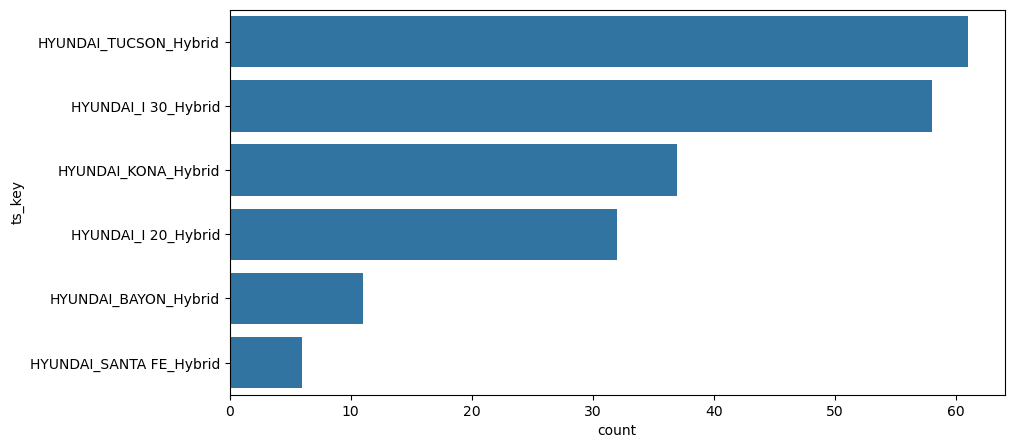

In [500]:
df_hyundai = df[df["oem"] == "HYUNDAI"]
df_hyundai_hybrid = df_hyundai[df_hyundai["type"] == "Hybrid"]
df_hyundai_hybrid = df_hyundai_hybrid[df_hyundai_hybrid["Value"]>300]
df_hyundai_hybrid.head()

# Visualization of the distribution of all samples over the 7 types
order = df_hyundai_hybrid["ts_key"].value_counts().index

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(y="ts_key", data=df_hyundai_hybrid, order=order, ax=ax)

plt.show()

In [501]:
#write all unique values in column ts_key of df_hyundai_hybrid
df_hyundai_hybrid['ts_key'].unique()

array(['HYUNDAI_BAYON_Hybrid', 'HYUNDAI_I 20_Hybrid',
       'HYUNDAI_I 30_Hybrid', 'HYUNDAI_KONA_Hybrid',
       'HYUNDAI_SANTA FE_Hybrid', 'HYUNDAI_TUCSON_Hybrid'], dtype=object)

### Time Trend Analysis

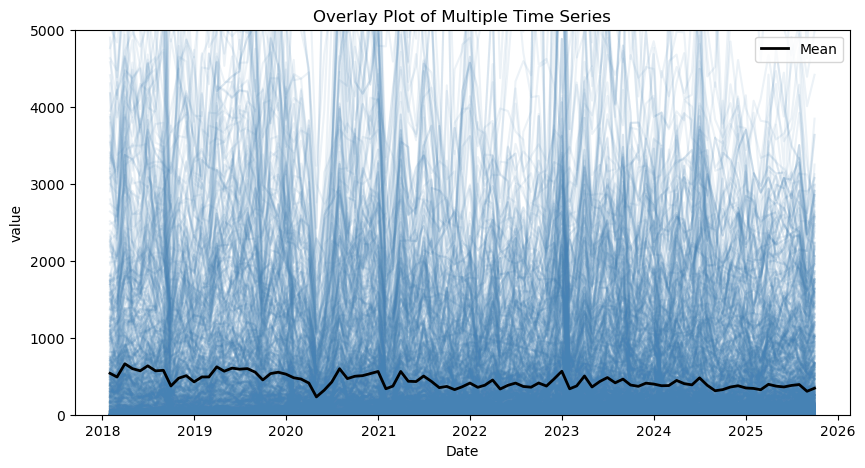

In [502]:
plt.figure(figsize=(10, 5))

for ts_key, g in df.groupby("ts_key"):
    plt.plot(g["Date"], g["Value"], alpha=0.1, color="steelblue")

plt.title("Overlay Plot of Multiple Time Series")
plt.xlabel("Date")
plt.ylabel("value")

mean_series = df.groupby("Date")["Value"].mean()
plt.plot(mean_series.index, mean_series, color="black", linewidth=2, label="Mean")
plt.legend()

# set y-axis scale to a maximum of 5000
plt.ylim(0, 5000)

plt.show()

An overlay plot was used to visualize the temporal structure of a large number of time series. Each series was plotted with high transparency to reveal global trends and heterogeneity across the dataset.


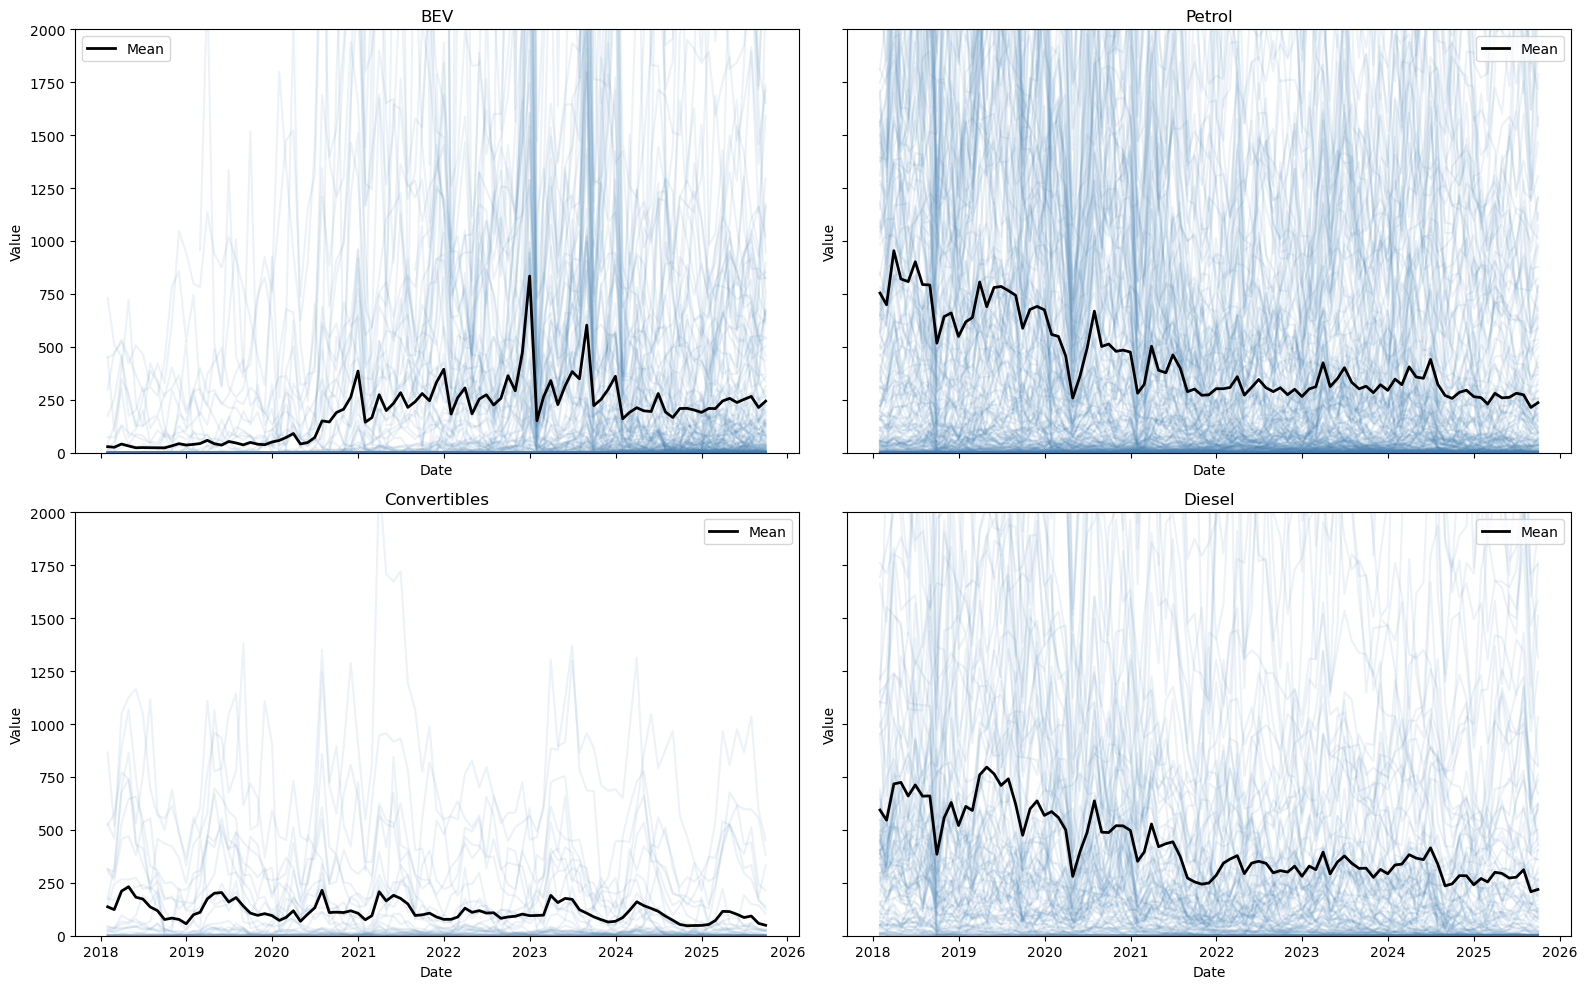

In [503]:
import matplotlib.pyplot as plt

vehicle_types = ["BEV", "Petrol", "Convertibles", "Diesel"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, v_type in zip(axes, vehicle_types):
    type_df = df[df["type"] == v_type].copy()
    type_df = type_df.sort_values("Date")

    # Overlay aller Zeitreihen
    for _, g in type_df.groupby("ts_key"):
        ax.plot(g["Date"], g["Value"], alpha=0.1, color="steelblue")

    # Mittelwert
    mean_series = type_df.groupby("Date")["Value"].mean()
    ax.plot(mean_series.index, mean_series, color="black", linewidth=2, label="Mean")

    ax.set_title(f"{v_type}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.set_ylim(0, 2000)
    ax.legend()

plt.tight_layout()
plt.show()


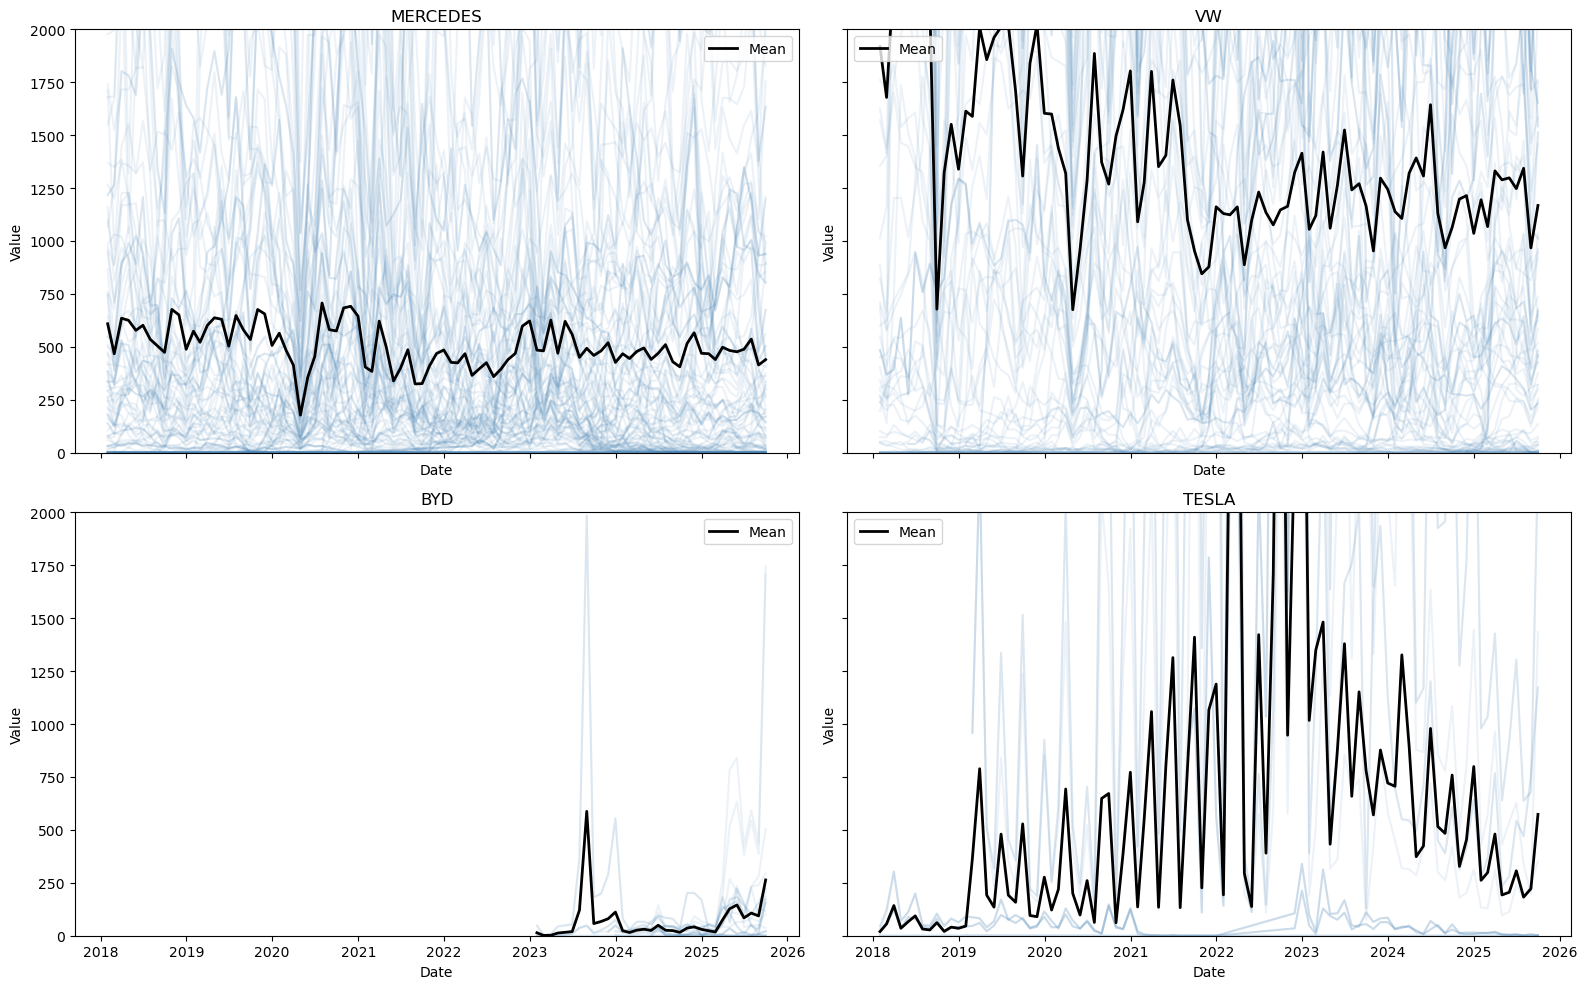

In [504]:
oems = ["MERCEDES", "VW", "BYD", "TESLA"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, v_type in zip(axes, oems):
    type_df = df[df["oem"] == v_type].copy()
    type_df = type_df.sort_values("Date")

    # Overlay aller Zeitreihen
    for _, g in type_df.groupby("ts_key"):
        ax.plot(g["Date"], g["Value"], alpha=0.1, color="steelblue")

    # Mittelwert
    mean_series = type_df.groupby("Date")["Value"].mean()
    ax.plot(mean_series.index, mean_series, color="black", linewidth=2, label="Mean")

    ax.set_title(f"{v_type}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.set_ylim(0, 2000)
    ax.legend()

plt.tight_layout()
plt.show()


When examining the registration numbers of battery electric vehicles (BEVs), random variations can be observed that cannot be attributed to trend or seasonal effects. These fluctuations are largely explained by changes in political support for this type of vehicle during specific time periods.

The overlay plot of petrol vehicle registration time series reveals a clear long-term downward trend. While individual time series exhibit substantial variability and short-term fluctuations, the aggregated mean (black line) shows a consistent decline over the observed period.

Registration numbers are relatively high in the early years (around 2018–2019), followed by a pronounced decrease starting in 2020. After this drop, the mean level remains persistently lower, with only minor short-term recoveries, indicating a structural change rather than a temporary fluctuation.

Overall, the trend suggests a sustained decline in petrol vehicle registrations over time, despite considerable heterogeneity across individual time series.*

When examining convertibles, a clear seasonality can be observed, characterized by a regular annual pattern since the beginning of the observation period.

The presence of such seasonal structures implies that machine learning models, particularly neural networks, must be capable of capturing periodic dependencies over time. This highlights the importance of incorporating sufficiently long input sequences or explicit seasonal features to enable the model to learn recurring annual patterns rather than treating them as noise.

###Autocorrelation

Autocorrelation shows how strongly current values of a time series depend on past values.
It helps identify whether the data contain meaningful temporal structure or are dominated by random noise.
Understanding autocorrelation is essential for selecting appropriate models and input sequence lengths, especially for neural networks such as LSTMs.
High autocorrelation indicates that past observations carry predictive information about future values.
Without analyzing autocorrelation, models may be poorly specified and fail to capture important temporal dependencies.

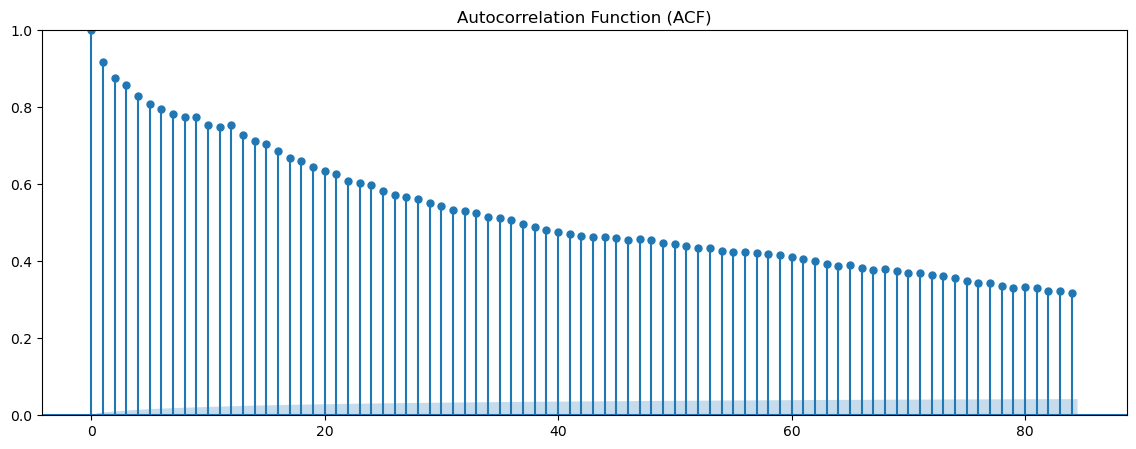

In [505]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(df["Value"], lags=84, ax=ax)

ax.set_title("Autocorrelation Function (ACF)")
ax.set_ylim(0, 1)

plt.show()

The autocorrelation function shows a strong and slowly decaying positive autocorrelation across many lags, indicating a highly persistent and non-stationary time series. The majority of autocorrelation values lie well outside the confidence interval, confirming that the temporal dependencies are statistically significant and not driven by random noise.

In addition to the average autocorrelation across all time series, category-specific autocorrelation analyses were conducted to account for structural heterogeneity between different powertrain types.

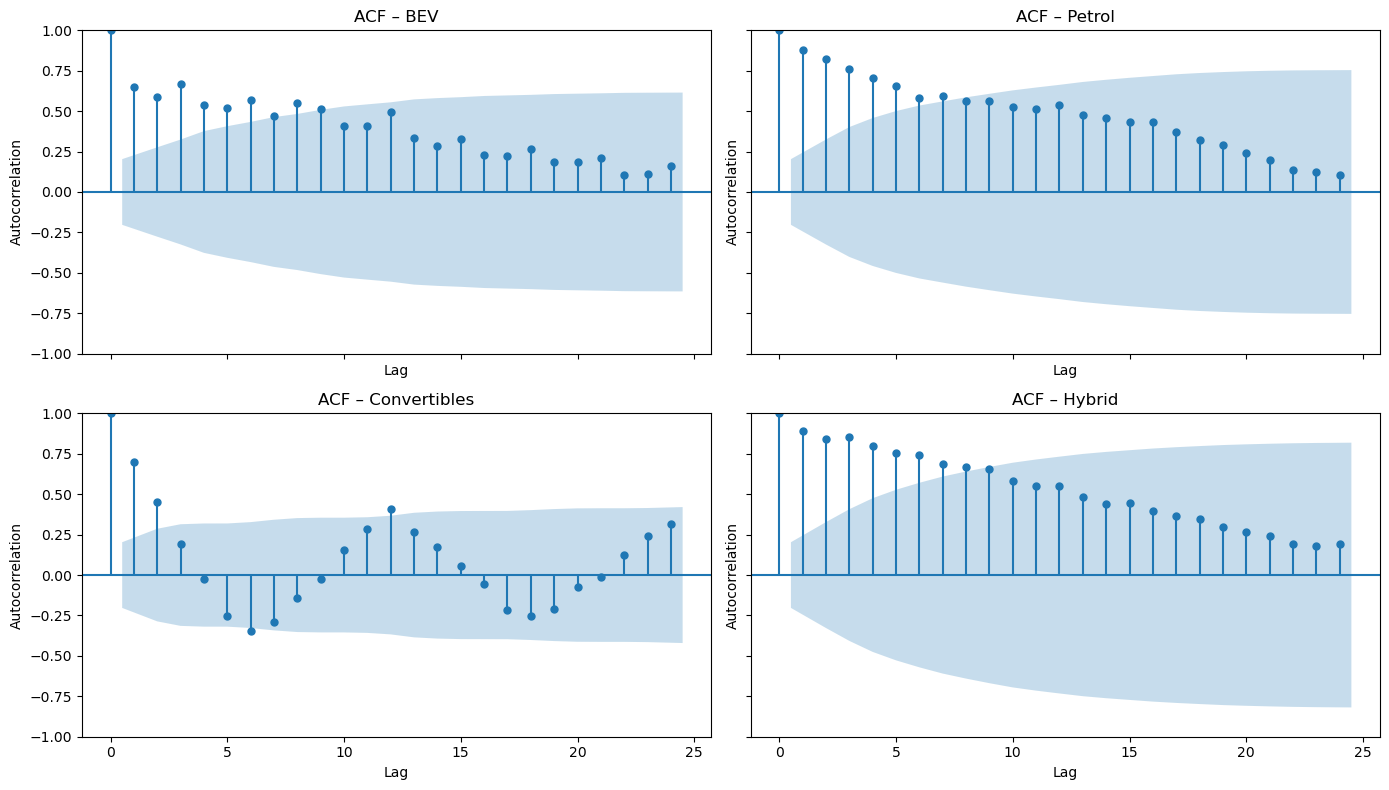

In [506]:
types = ["BEV", "Petrol", "Convertibles", "Hybrid"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, t in zip(axes, types):
    df_type = df[df["type"] == t].copy()
    df_type = df_type.sort_values("Date")

    # Aggregierte Zeitreihe (Mean pro Date)
    series = df_type.groupby("Date")["Value"].mean()
    series = series.dropna()

    plot_acf(series, lags=24, ax=ax)
    ax.set_title(f"ACF – {t}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

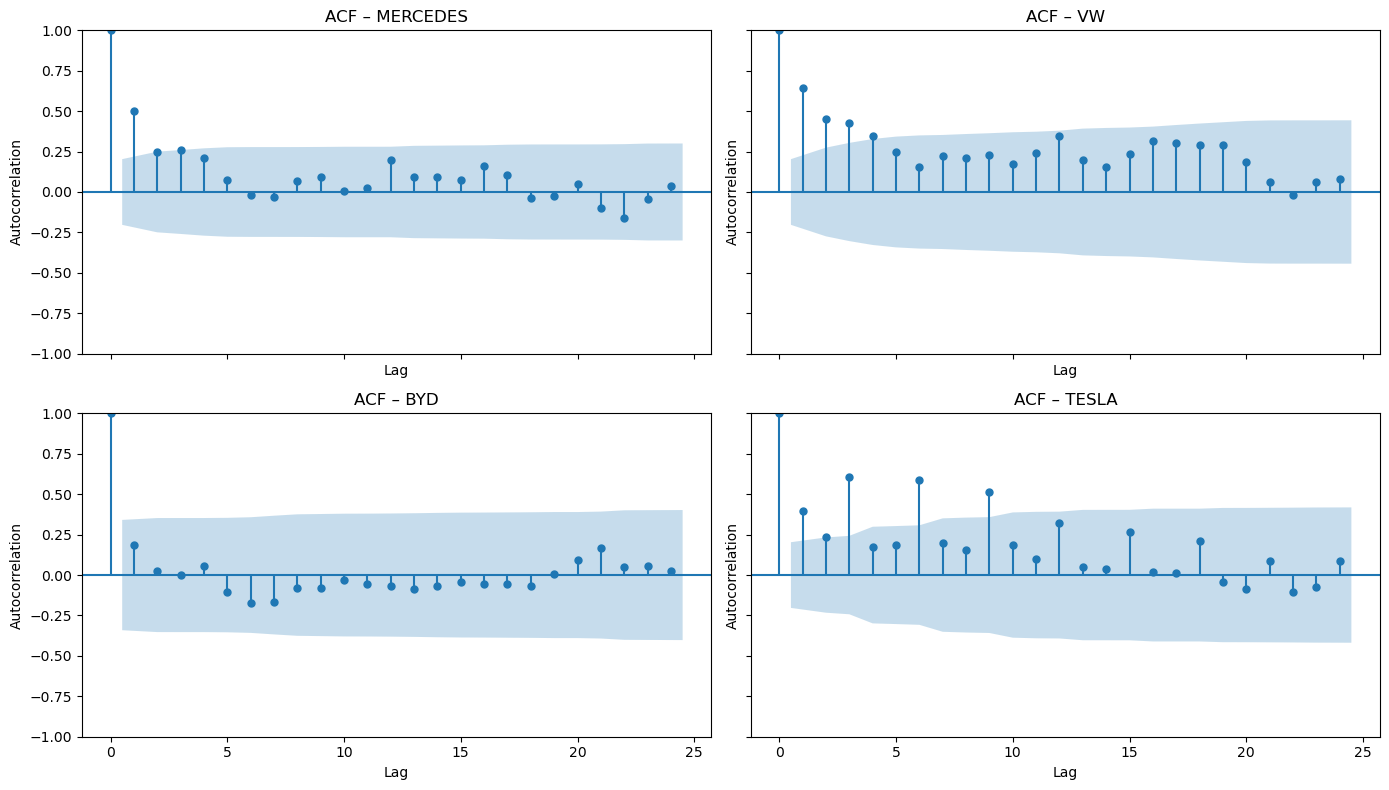

In [507]:
oems = ["MERCEDES", "VW", "BYD", "TESLA"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, oem in zip(axes, oems):
    df_oem = df[df["oem"] == oem].copy()
    df_oem = df_oem.sort_values("Date")

    # Aggregierte Zeitreihe (Mean pro Date)
    series = df_oem.groupby("Date")["Value"].mean()
    series = series.dropna()

    plot_acf(series, lags=24, ax=ax)
    ax.set_title(f"ACF – {oem}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

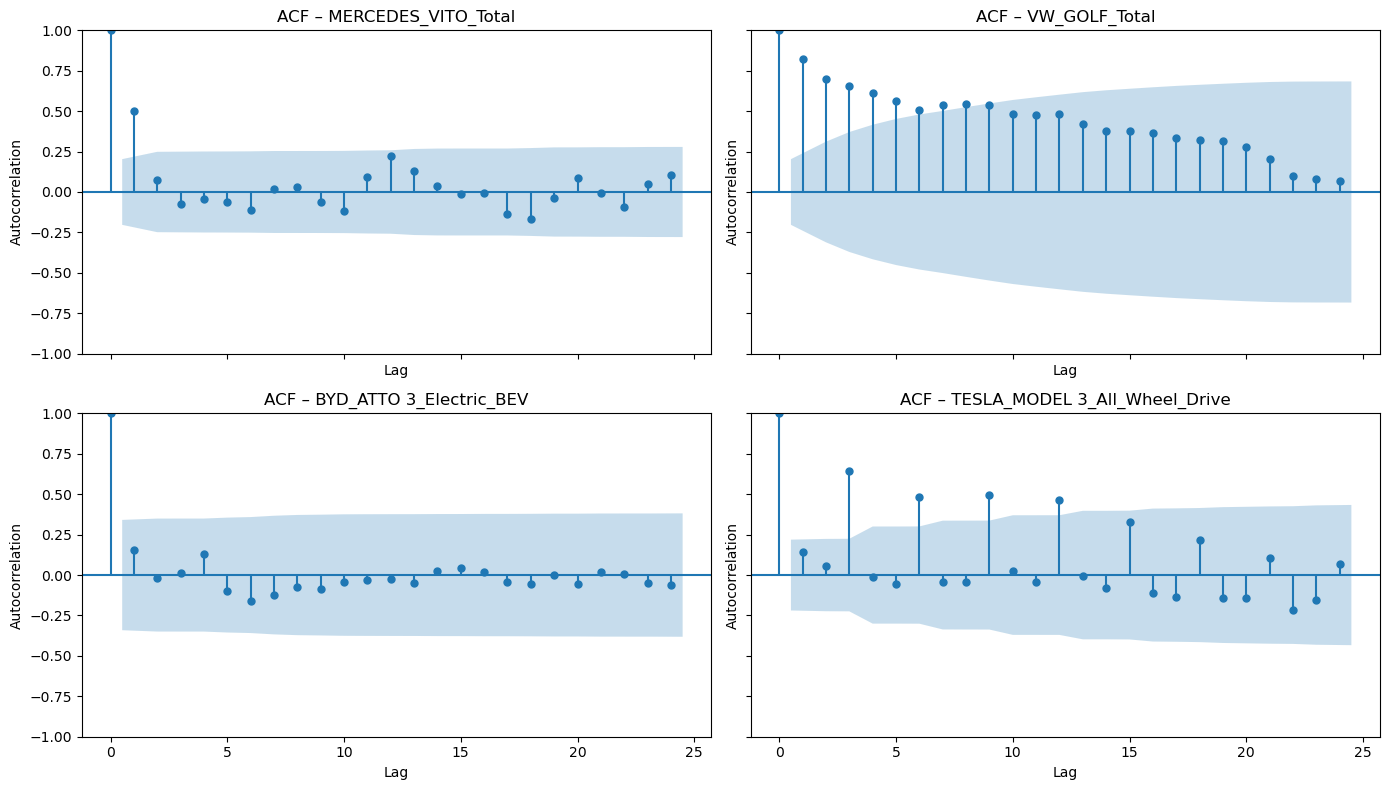

In [508]:
ts_keys = [
    "MERCEDES_VITO_Total",
    "VW_GOLF_Total",
    "BYD_ATTO 3_Electric_BEV",
    "TESLA_MODEL 3_All_Wheel_Drive"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, key in zip(axes, ts_keys):
    df_ts = df[df["ts_key"] == key].copy()
    df_ts = df_ts.sort_values("Date")

    series = df_ts["Value"].dropna()

    plot_acf(series, lags=24, ax=ax)
    ax.set_title(f"ACF – {key}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()


### Time dependent mulitvariate correlation

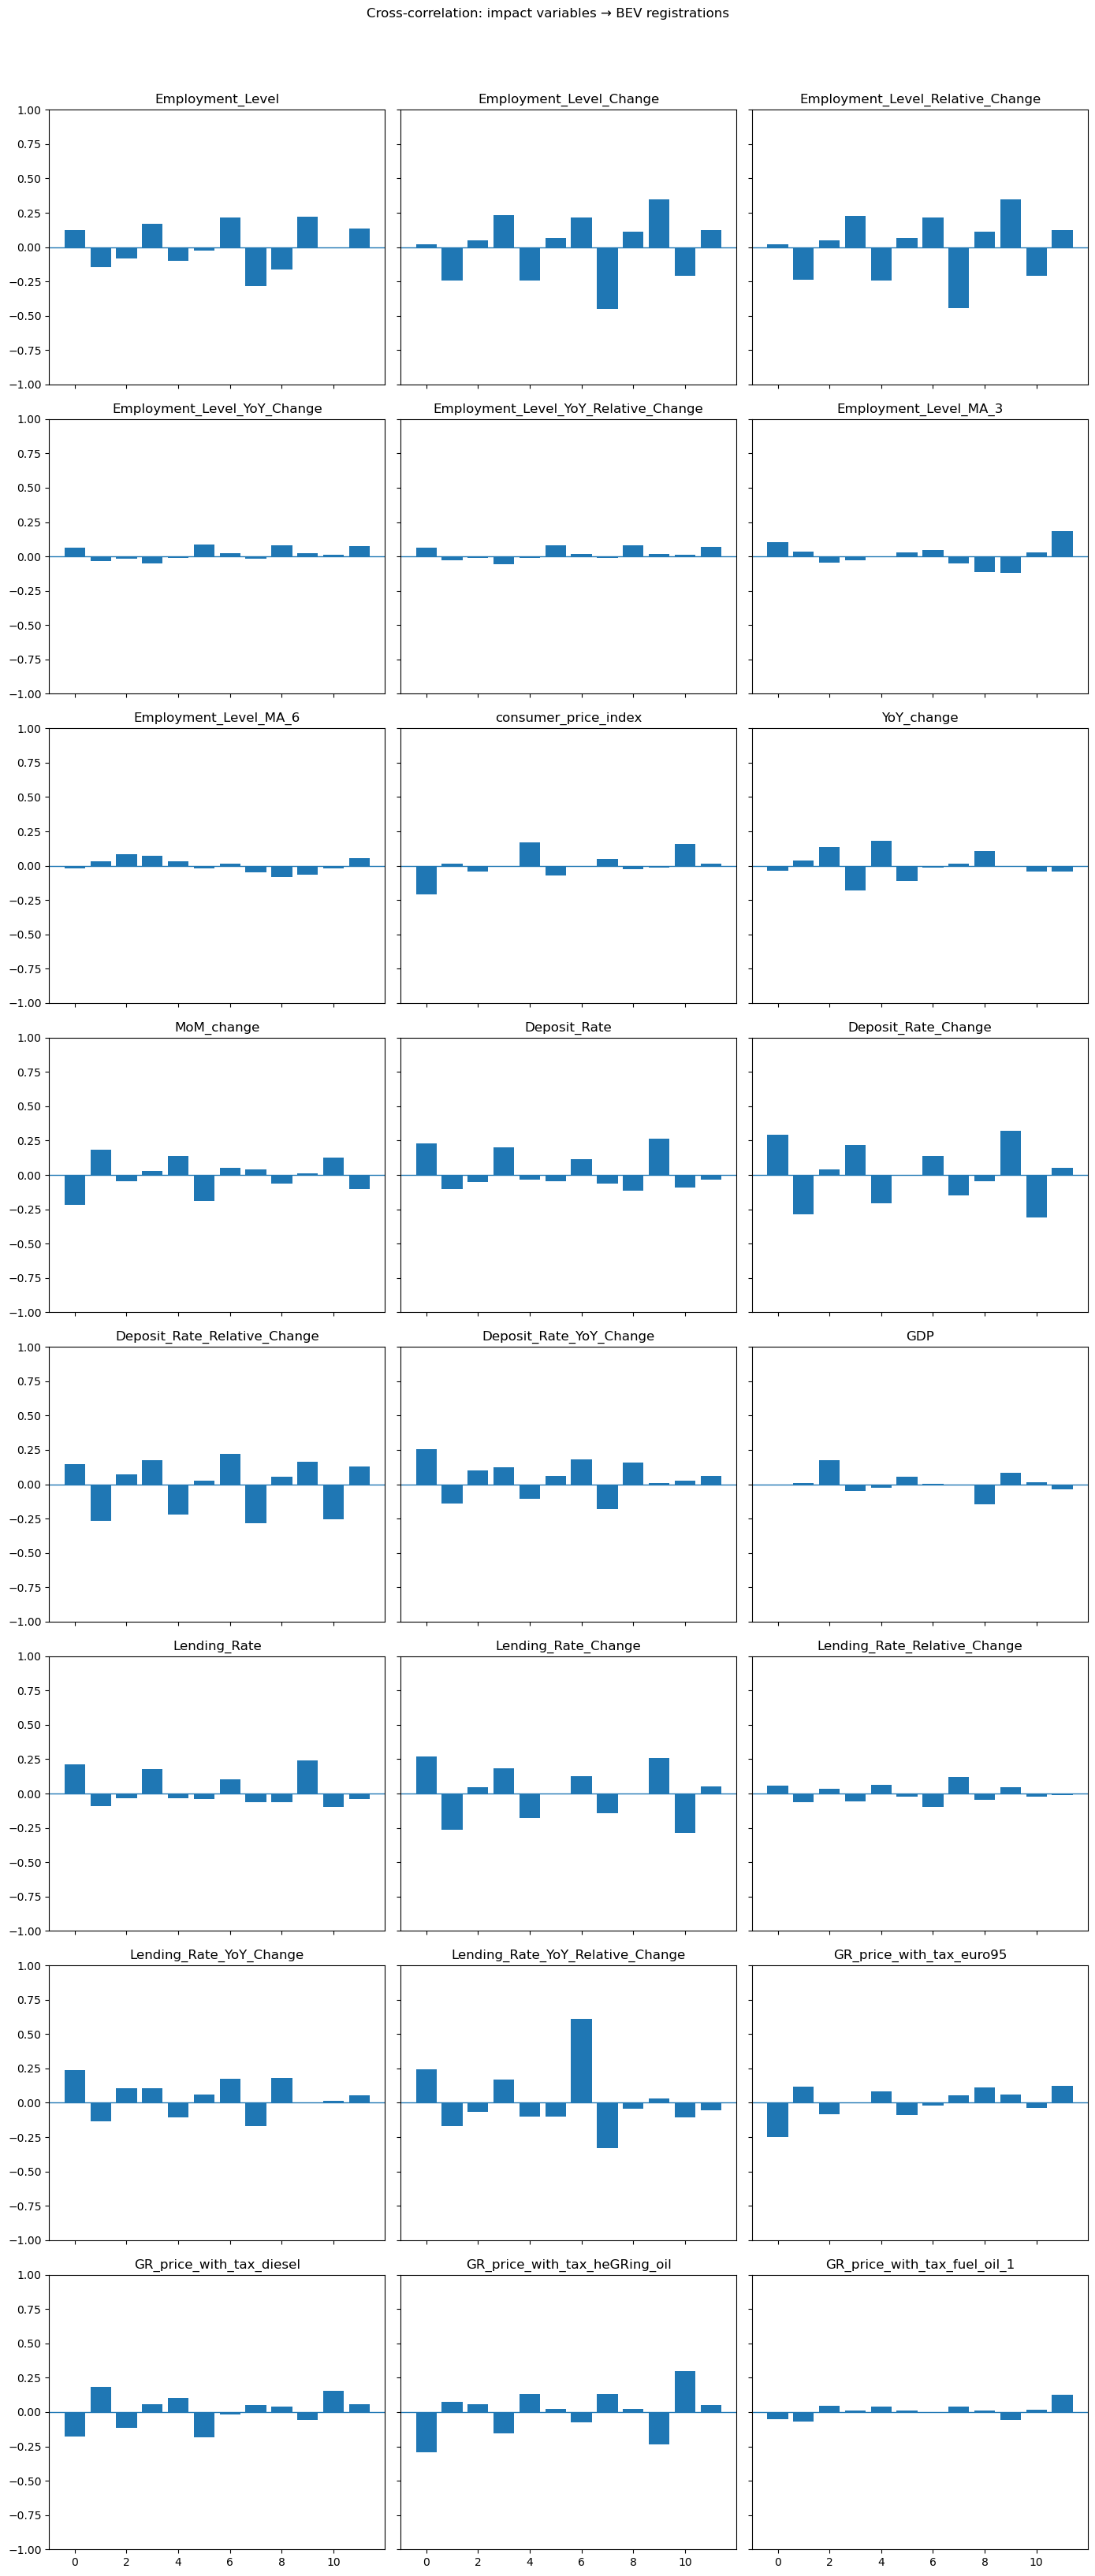

In [528]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Target series (choose type here)
target_type = "BEV"
target = df[df["type"] == target_type].groupby("Date")["Value"].mean()

# Impact columns (numeric only)
exclude = {"Date", "ts_key", "Value", "type", "oem"}
impact_cols = [c for c in df.select_dtypes("number").columns if c not in exclude]

n_cols = 3
n_rows = math.ceil(len(impact_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=True, sharey=True)
axes = np.ravel(axes)

for ax, col in zip(axes, impact_cols):
    impact = df.groupby("Date")[col].mean()
    d = pd.concat([impact, target], axis=1).dropna().diff().dropna()
    d = (d - d.mean()) / d.std()

    lags = min(12, len(d) - 1)
    if lags < 2 or d.isna().any().any():
        ax.axis("off"); continue

    cc = ccf(d.iloc[:, 0], d.iloc[:, 1])[:lags]
    ax.bar(range(lags), cc)
    ax.axhline(0, linewidth=1)
    ax.set_title(col)
    ax.set_ylim(-1, 1)

for ax in axes[len(impact_cols):]:
    ax.remove()

fig.suptitle(f"Cross-correlation: impact variables → {target_type} registrations", y=1.02)
plt.tight_layout()
plt.show()

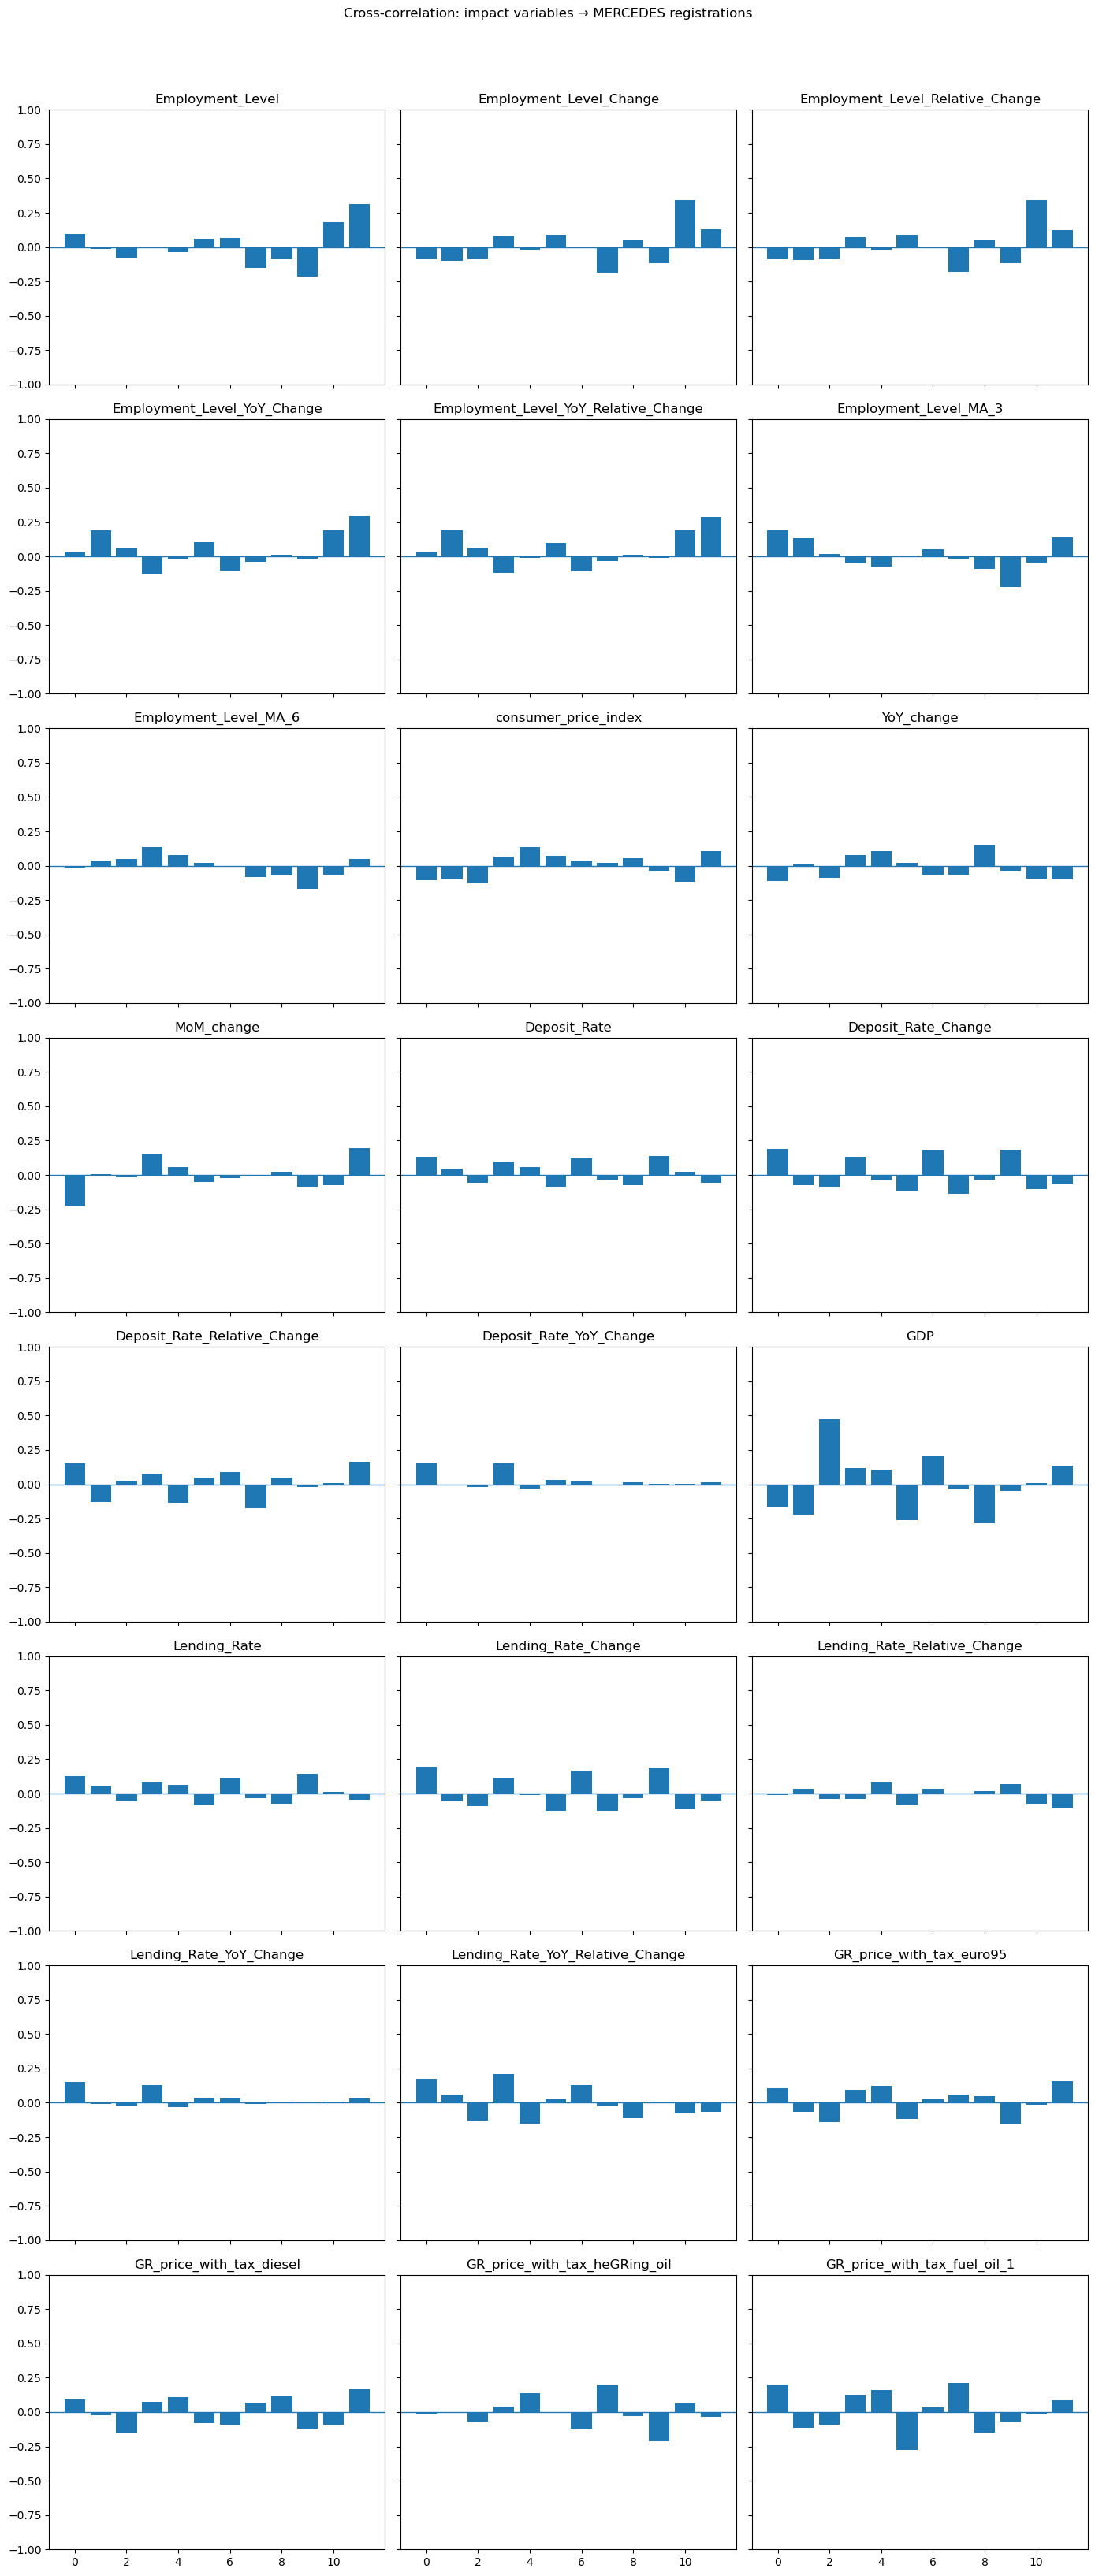

In [527]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Target series (choose type here)
target_oem = "MERCEDES"
target = df[df["oem"] == target_oem].groupby("Date")["Value"].mean()

# Impact columns (numeric only)
exclude = {"Date", "ts_key", "Value", "type", "oem"}
impact_cols = [c for c in df.select_dtypes("number").columns if c not in exclude]

n_cols = 3
n_rows = math.ceil(len(impact_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=True, sharey=True)
axes = np.ravel(axes)

for ax, col in zip(axes, impact_cols):
    impact = df.groupby("Date")[col].mean()
    d = pd.concat([impact, target], axis=1).dropna().diff().dropna()
    d = (d - d.mean()) / d.std()

    lags = min(12, len(d) - 1)
    if lags < 2 or d.isna().any().any():
        ax.axis("off"); continue

    cc = ccf(d.iloc[:, 0], d.iloc[:, 1])[:lags]
    ax.bar(range(lags), cc)
    ax.axhline(0, linewidth=1)
    ax.set_title(col)
    ax.set_ylim(-1, 1)

for ax in axes[len(impact_cols):]:
    ax.remove()

fig.suptitle(f"Cross-correlation: impact variables → {target_oem} registrations", y=1.02)
plt.tight_layout()
plt.show()

In [525]:
Tesla_list = df[df['oem']=='MERCEDES']['ts_key'].unique().tolist()
Tesla_list

['MERCEDES_A-KLASSE_Diesel',
 'MERCEDES_A-KLASSE_Hybrid',
 'MERCEDES_VITO_Hybrid',
 'MERCEDES_VITO_Total',
 'MERCEDES_VITO_Electric_BEV',
 'MERCEDES_VITO_Petrol',
 'MERCEDES_A-KLASSE_All_Wheel_Drive',
 'MERCEDES_GLK, GLC_Total',
 'MERCEDES_ML-KLASSE, GLE_All_Wheel_Drive',
 'MERCEDES_ML-KLASSE, GLE_Diesel',
 'MERCEDES_AMG GT_Total',
 'MERCEDES_B-KLASSE_All_Wheel_Drive',
 'MERCEDES_B-KLASSE_Hybrid',
 'MERCEDES_B-KLASSE_Total',
 'MERCEDES_C-KLASSE_Convertibles',
 'MERCEDES_S-KLASSE_Diesel',
 'MERCEDES_S-KLASSE_Electric_BEV',
 'MERCEDES_S-KLASSE_Hybrid',
 'MERCEDES_S-KLASSE_Petrol',
 'MERCEDES_S-KLASSE_Total',
 'MERCEDES_ML-KLASSE, GLE_Hybrid',
 'MERCEDES_ML-KLASSE, GLE_Petrol',
 'MERCEDES_ML-KLASSE, GLE_Total',
 'MERCEDES_S-KLASSE_All_Wheel_Drive',
 'MERCEDES_GLK, GLC_Petrol',
 'MERCEDES_GLK, GLC_Hybrid',
 'MERCEDES_SL_All_Wheel_Drive',
 'MERCEDES_AMG GT_Petrol',
 'MERCEDES_CITAN_Petrol',
 'MERCEDES_B-KLASSE_Diesel',
 'MERCEDES_B-KLASSE_Petrol',
 'MERCEDES_C-KLASSE_All_Wheel_Drive',
 'MER

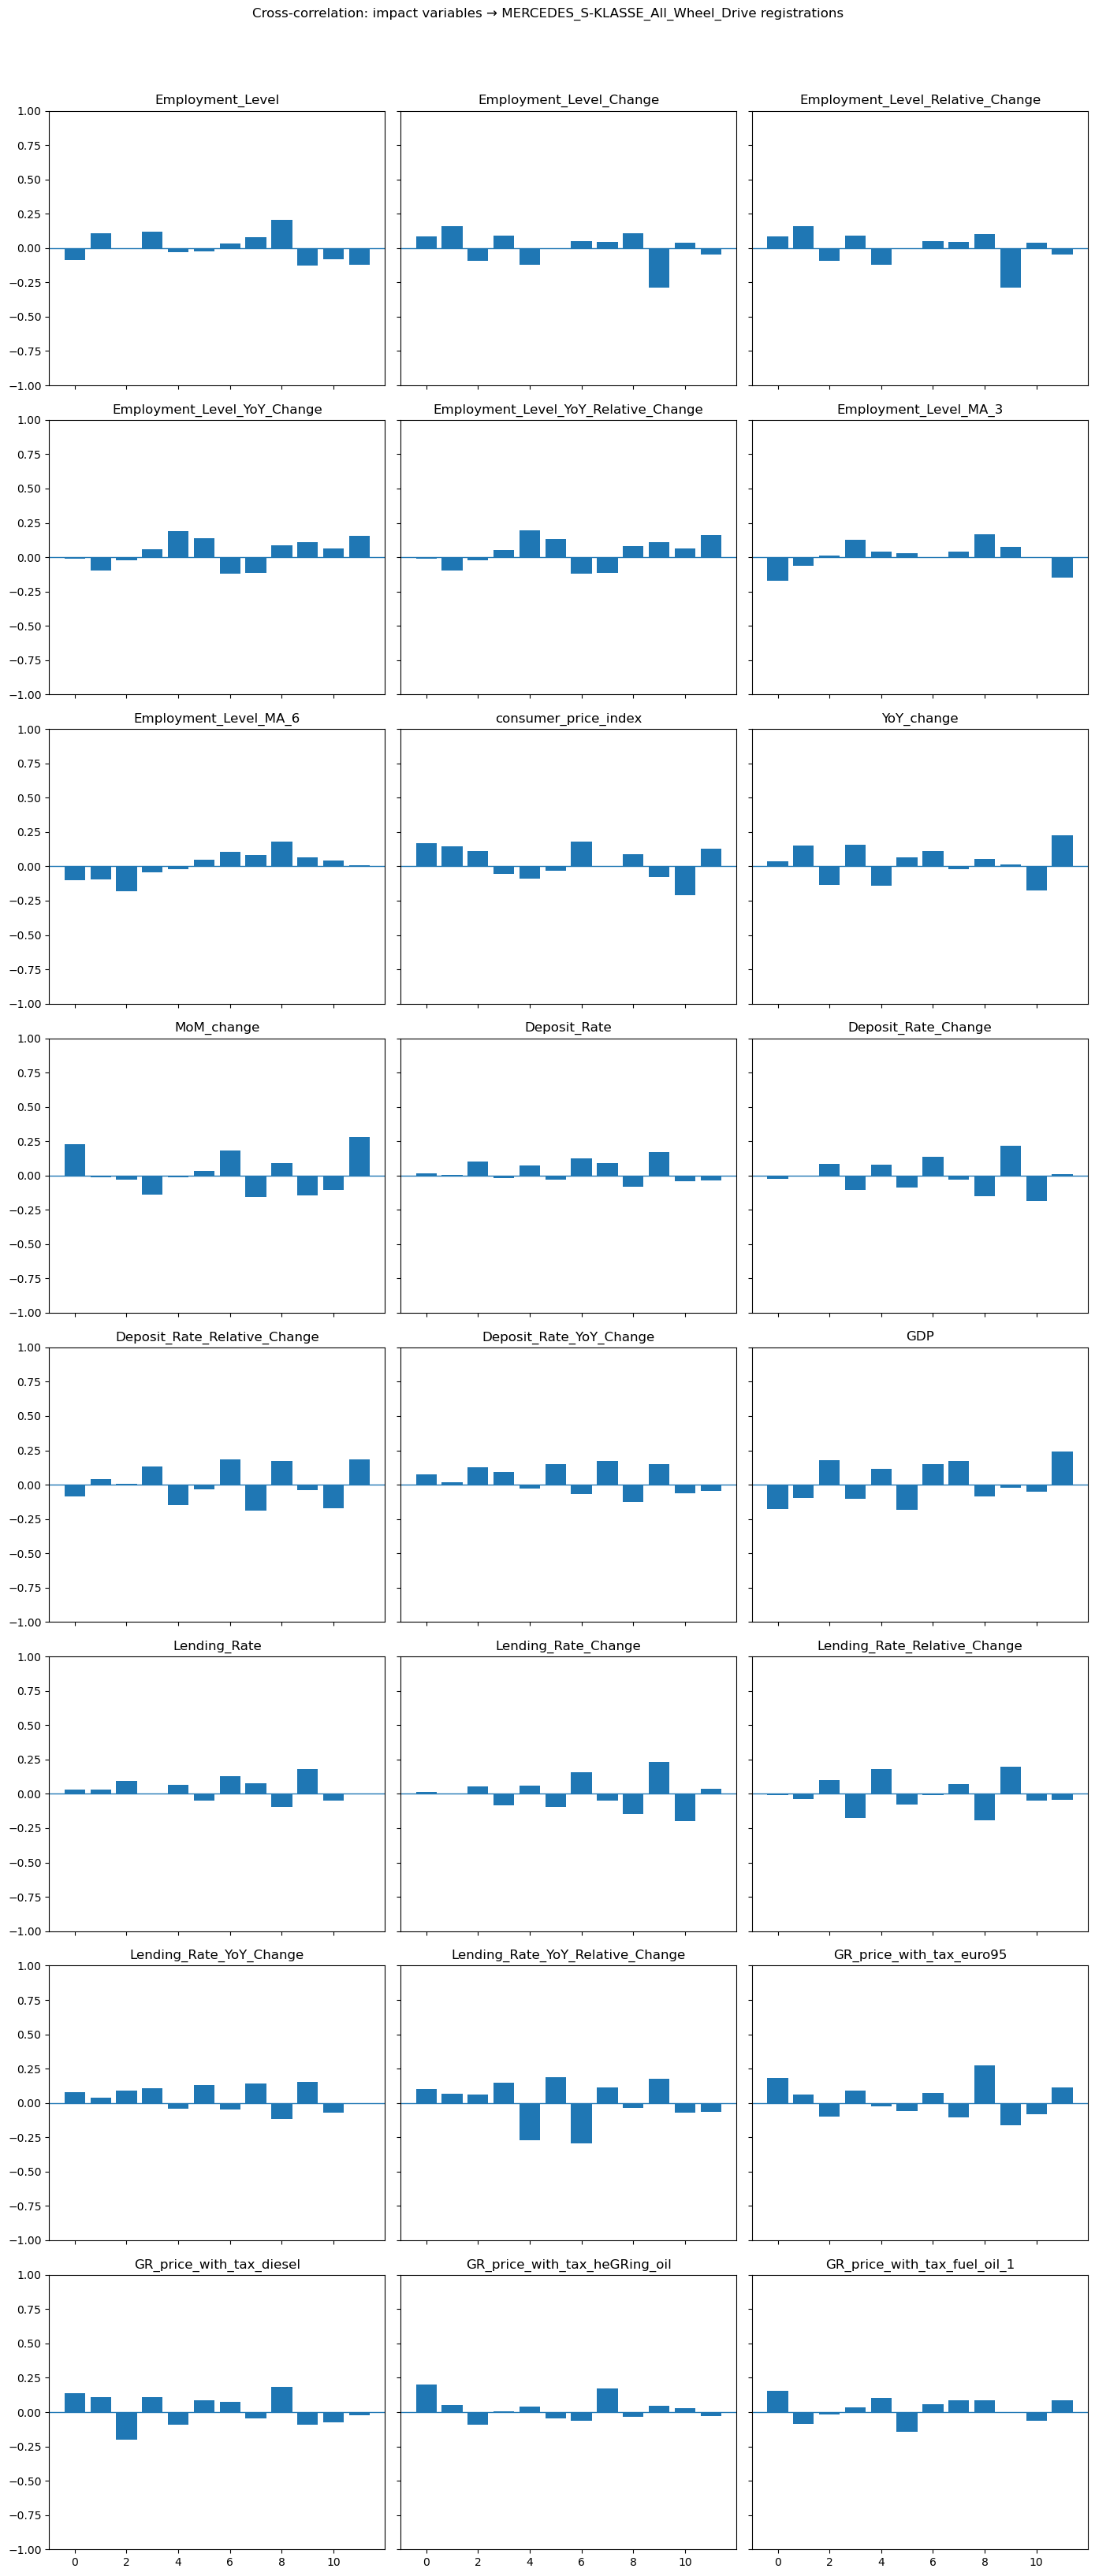

In [529]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Target series (choose type here)
target_model = "MERCEDES_S-KLASSE_All_Wheel_Drive"
target = df[df["ts_key"] == target_model].groupby("Date")["Value"].mean()

# Impact columns (numeric only)
exclude = {"Date", "ts_key", "Value", "type", "oem"}
impact_cols = [c for c in df.select_dtypes("number").columns if c not in exclude]

n_cols = 3
n_rows = math.ceil(len(impact_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=True, sharey=True)
axes = np.ravel(axes)

for ax, col in zip(axes, impact_cols):
    impact = df.groupby("Date")[col].mean()
    d = pd.concat([impact, target], axis=1).dropna().diff().dropna()
    d = (d - d.mean()) / d.std()

    lags = min(12, len(d) - 1)
    if lags < 2 or d.isna().any().any():
        ax.axis("off"); continue

    cc = ccf(d.iloc[:, 0], d.iloc[:, 1])[:lags]
    ax.bar(range(lags), cc)
    ax.axhline(0, linewidth=1)
    ax.set_title(col)
    ax.set_ylim(-1, 1)

for ax in axes[len(impact_cols):]:
    ax.remove()

fig.suptitle(f"Cross-correlation: impact variables → {target_model} registrations", y=1.02)
plt.tight_layout()
plt.show()